In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
import requests

from sklearn.model_selection import KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

ionosphere

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/ionosphere/ionosphere.data"

df_ion = pd.read_csv(url, header=None)

X_ion = df_ion.iloc[:, :-1].values
y_ion = df_ion.iloc[:, -1].values

le = LabelEncoder()
y_ion = le.fit_transform(y_ion)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)


In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "SVM": make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True)),
    "MLP (Neural Net)": make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42))
}

results = {}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_ion, y_ion, cv=kfold, scoring='balanced_accuracy')
    results[name] = cv_scores
    print(f"{name}: Mean Balanced Accuracy = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Decision Tree: Mean Balanced Accuracy = 0.8817 (+/- 0.0158)
Random Forest: Mean Balanced Accuracy = 0.9221 (+/- 0.0295)
Logistic Regression: Mean Balanced Accuracy = 0.8384 (+/- 0.0464)
SVM: Mean Balanced Accuracy = 0.9259 (+/- 0.0367)
MLP (Neural Net): Mean Balanced Accuracy = 0.8821 (+/- 0.0522)


In [ ]:
print("First 5 rows of the dataset:")
display(df_ion.head())

print("\nDataset Information:")
df_ion.info()

print("\nStatistical Summary:")
display(df_ion.describe())

First 5 rows of the dataset:


,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,32,33,34
0,1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,g
1,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,b
2,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,g
3,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,b
4,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,g



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 35 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       351 non-null    int64  
 1   1       351 non-null    int64  
 2   2       351 non-null    float64
 3   3       351 non-null    float64
 4   4       351 non-null    float64
 5   5       351 non-null    float64
 6   6       351 non-null    float64
 7   7       351 non-null    float64
 8   8       351 non-null    float64
 9   9       351 non-null    float64
 10  10      351 non-null    float64
 11  11      351 non-null    float64
 12  12      351 non-null    float64
 13  13      351 non-null    float64
 14  14      351 non-null    float64
 15  15      351 non-null    float64
 16  16      351 non-null    float64
 17  17      351 non-null    float64
 18  18      351 non-null    float64
 19  19      351 non-null    float64
 20  20      351 non-null    float64
 21  21      351 non-n

,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,33
count,351.000000,351.0,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,...,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000
mean,0.891738,0.0,0.641342,0.044372,0.601068,0.115889,0.550095,0.119360,0.511848,0.181345,...,0.396135,-0.071187,0.541641,-0.069538,0.378445,-0.027907,0.352514,-0.003794,0.349364,0.014480
std,0.311155,0.0,0.497708,0.441435,0.519862,0.460810,0.492654,0.520750,0.507066,0.483851,...,0.578451,0.508495,0.516205,0.550025,0.575886,0.507974,0.571483,0.513574,0.522663,0.468337
min,0.000000,0.0,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,1.000000,0.0,0.472135,-0.064735,0.412660,-0.024795,0.211310,-0.054840,0.087110,-0.048075,...,0.000000,-0.332390,0.286435,-0.443165,0.000000,-0.236885,0.000000,-0.242595,0.000000,-0.165350
50%,1.000000,0.0,0.871110,0.016310,0.809200,0.022800,0.728730,0.014710,0.684210,0.018290,...,0.553890,-0.015050,0.708240,-0.017690,0.496640,0.000000,0.442770,0.000000,0.409560,0.000000
75%,1.000000,0.0,1.000000,0.194185,1.000000,0.334655,0.969240,0.445675,0.953240,0.534195,...,0.905240,0.156765,0.999945,0.153535,0.883465,0.154075,0.857620,0.200120,0.813765,0.171660
max,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
print("Missing values per column:")
missing_values = df_ion.isnull().sum()
print(missing_values)

if missing_values.sum() == 0:
    print("\nSummary: No missing values detected. The dataset is complete.")
else:
    print(f"\nSummary: Found {missing_values.sum()} missing values.")

Missing values per column:
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
29    0
30    0
31    0
32    0
33    0
34    0
dtype: int64

Summary: No missing values detected. The dataset is complete.


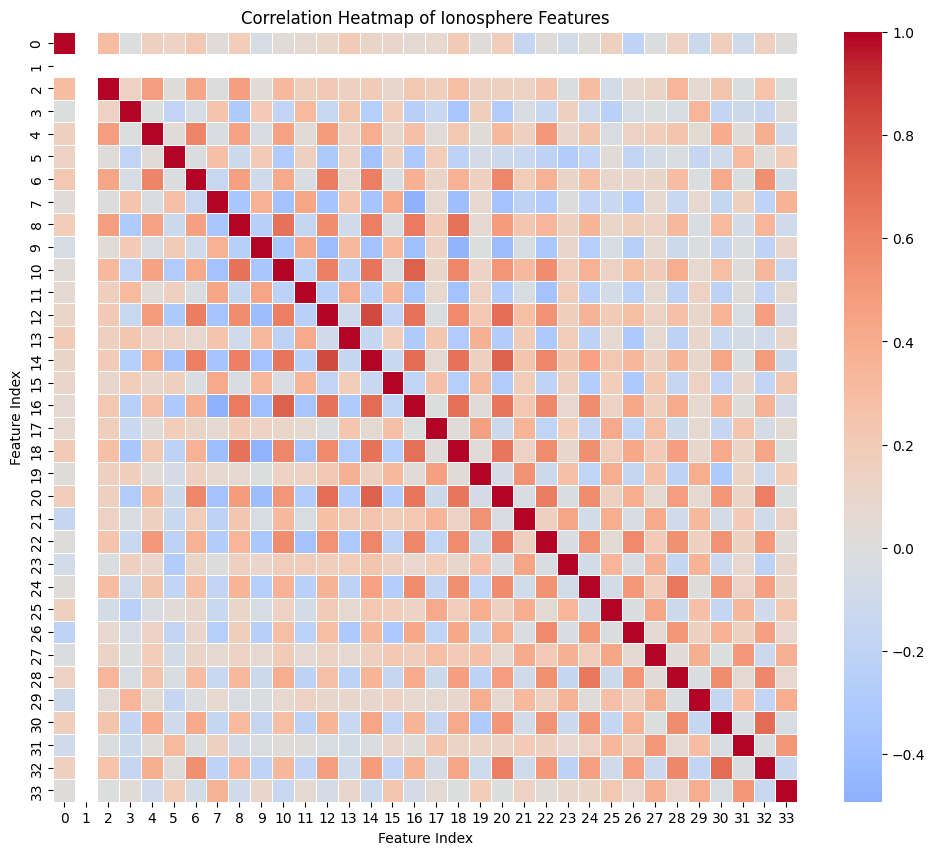

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_ion.iloc[:, :-1].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)

plt.title('Correlation Heatmap of Ionosphere Features')
plt.xlabel('Feature Index')
plt.ylabel('Feature Index')

plt.show()

In [ ]:
constant_cols = [col for col in df_ion.columns[:-1] if df_ion[col].nunique() <= 1]
print(f"Constant columns identified: {constant_cols}")

df_ion_cleaned = df_ion.drop(columns=constant_cols)

X_ion = df_ion_cleaned.iloc[:, :-1].values

print(f"Original shape: {df_ion.shape}")
print(f"Cleaned shape: {df_ion_cleaned.shape}")
print(f"Updated X_ion shape: {X_ion.shape}")

Constant columns identified: [1]
Original shape: (351, 35)
Cleaned shape: (351, 34)
Updated X_ion shape: (351, 33)


In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "SVM": make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True)),
    "MLP (Neural Net)": make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42))
}

results = {}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_ion, y_ion, cv=kfold, scoring='balanced_accuracy')
    results[name] = cv_scores
    print(f"{name}: Mean Balanced Accuracy = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Decision Tree: Mean Balanced Accuracy = 0.8757 (+/- 0.0300)
Random Forest: Mean Balanced Accuracy = 0.9159 (+/- 0.0397)
Logistic Regression: Mean Balanced Accuracy = 0.8384 (+/- 0.0464)
SVM: Mean Balanced Accuracy = 0.9259 (+/- 0.0367)
MLP (Neural Net): Mean Balanced Accuracy = 0.8883 (+/- 0.0556)


space.csv

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):
    markers = ("o", "s", "^", "v", "<")
    colors = ("blue", "red", "lightgreen", "gray", "cyan")
    cmap = ListedColormap(colors[:len(np.unique(y))])

    x1_min, x1_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    x2_min, x2_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))

    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)

    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl].iloc[:, 0],
                    y=X[y == cl].iloc[:, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=f"Class {cl}",
                    edgecolor="black")

In [ ]:
df_space = pd.read_csv('/content/space.csv')

print("Columns in space dataset:", df_space.columns.tolist())
display(df_space.head())

numeric_cols = df_space.select_dtypes(include=[np.number]).columns.tolist()
target_col = df_space.columns[-1]

selected_features = [col for col in ['ra', 'dec'] if col in numeric_cols]
if len(selected_features) < 2:
    selected_features = numeric_cols[:2]

print(f"\nSelected features for X_space: {selected_features}")
print(f"Selected target column for y_space: {target_col}")

X_space = df_space[selected_features]
y_space_raw = df_space[target_col]

le_space = LabelEncoder()
y_space = le_space.fit_transform(y_space_raw)

print(f"\nShape of X_space: {X_space.shape}")
print(f"Unique values in encoded y_space: {np.unique(y_space)}")
print(f"Label mapping: {dict(zip(le_space.classes_, le_space.transform(le_space.classes_)))}")

Columns in space dataset: ['x', 'y', 'label']


,x,y,label
0,-0.854800,-0.010376,0.0
1,0.355699,-0.519722,0.0
2,0.095440,0.777868,0.0
3,0.931966,-0.055718,0.0
4,-0.105374,0.987070,0.0



Selected features for X_space: ['x', 'y']
Selected target column for y_space: label

Shape of X_space: (898, 2)
Unique values in encoded y_space: [0 1]
Label mapping: {np.float64(0.0): np.int64(0), np.float64(1.0): np.int64(1)}


In [ ]:
models_space = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)),
    "SVM": make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, random_state=42)),
    "MLP (Neural Net)": make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42))
}

fitted_models_space = {}

for name, model in models_space.items():
    model.fit(X_space, y_space)
    fitted_models_space[name] = model
    print(f"{name} model trained successfully.")

Decision Tree model trained successfully.
Random Forest model trained successfully.
Logistic Regression model trained successfully.
SVM model trained successfully.
MLP (Neural Net) model trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


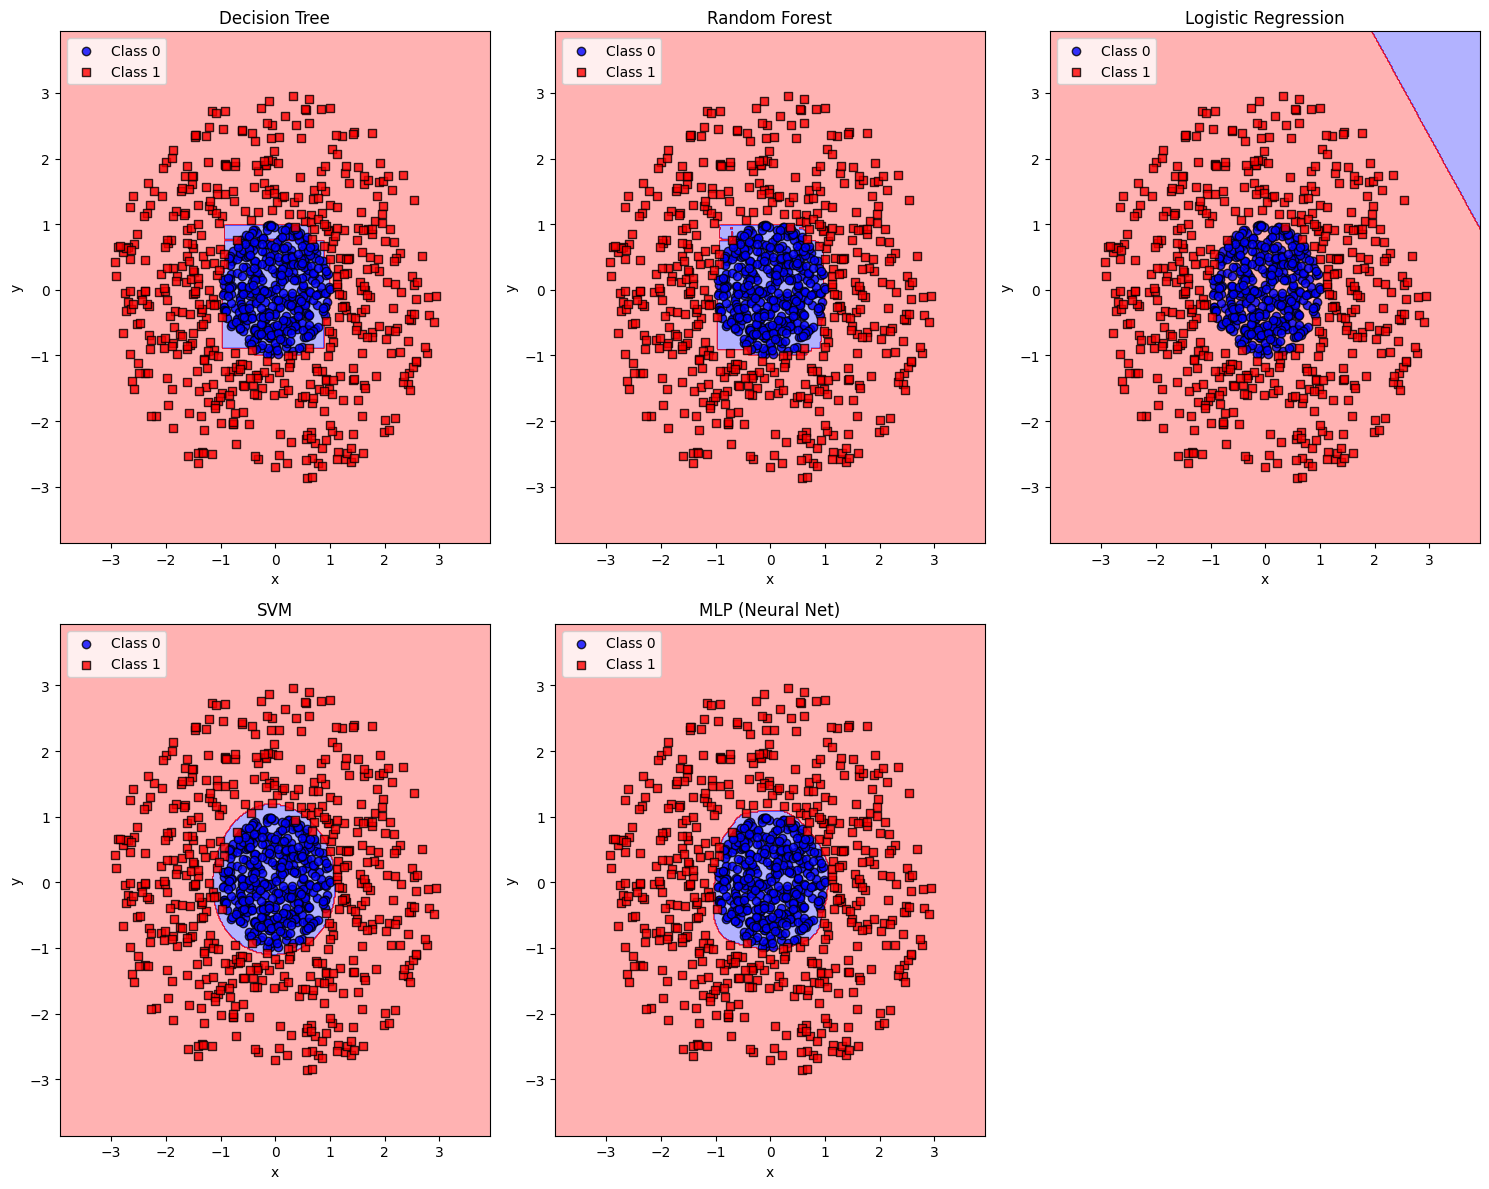

In [ ]:
plt.figure(figsize=(15, 12))

for i, (name, model) in enumerate(fitted_models_space.items(), 1):
    plt.subplot(2, 3, i)
    plot_decision_regions(X_space, y_space, classifier=model)
    plt.title(name)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

Syntetyczne dane

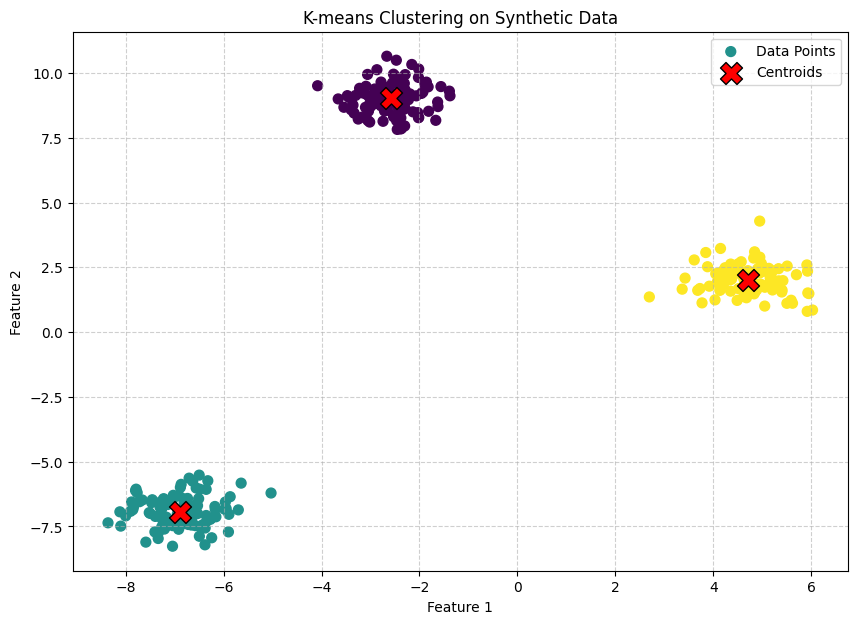

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X_synth, y_true = make_blobs(n_samples=300, centers=3, n_features=2, cluster_std=0.60, random_state=42)

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')

y_kmeans = kmeans.fit_predict(X_synth)

centers = kmeans.cluster_centers_

plt.figure(figsize=(10, 7))

plt.scatter(X_synth[:, 0], X_synth[:, 1], c=y_kmeans, s=50, cmap='viridis', label='Data Points')

plt.scatter(centers[:, 0], centers[:, 1], c='red', s=250, marker='X', edgecolors='black', label='Centroids')

plt.title('K-means Clustering on Synthetic Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()